In [2]:
import pandas as pd
import numpy as np

# Fundamental constants
G = 6.6743e-11        # m^3 / (kg * s^2)
a_kappa = 7.02e-11    # m / s^2 (WILL RG horizon acceleration)
M_sun = 1.98847e30    # kg
Mpc = 3.08567758e22   # m

# Initial observational data for clusters
data = {
    'Cluster': ['Coma (Abell 1656)', 'Virgo', 'Perseus (Abell 426)'],
    'M_baryon_Msun': [3.0e14, 5.0e13, 1.3e14],
    'Radius_Mpc': [3.0, 2.0, 2.0],
    'Sigma_obs_km_s': [1000, 700, 1000] # Observed values
}

df = pd.DataFrame(data)

# Convert to SI units
df['M_baryon_kg'] = df['M_baryon_Msun'] * M_sun
df['Radius_m'] = df['Radius_Mpc'] * Mpc

# 1. Local Newtonian potential (velocity squared)
df['V_N_sq'] = (G * df['M_baryon_kg']) / df['Radius_m']

# 2. Resonance interference term with the horizon
df['Interference'] = np.sqrt(df['V_N_sq'] * a_kappa * df['Radius_m'])

# 3. Calculate predicted dispersion (WILL RG 3D balance equation: 2*sigma^2 = V_N^2 + Interference)
df['Sigma_pred_sq'] = (df['V_N_sq'] + df['Interference']) / 2
df['Sigma_pred_km_s'] = np.sqrt(df['Sigma_pred_sq']) / 1000

# Formatted output
print(df[['Cluster', 'M_baryon_Msun', 'Sigma_obs_km_s', 'Sigma_pred_km_s']])

# Save to file
df.to_csv('cluster_predictions.csv', index=False)

               Cluster  M_baryon_Msun  Sigma_obs_km_s  Sigma_pred_km_s
0    Coma (Abell 1656)   3.000000e+14            1000      1025.166481
1                Virgo   5.000000e+13             700       628.508975
2  Perseus (Abell 426)   1.300000e+14            1000       830.692460


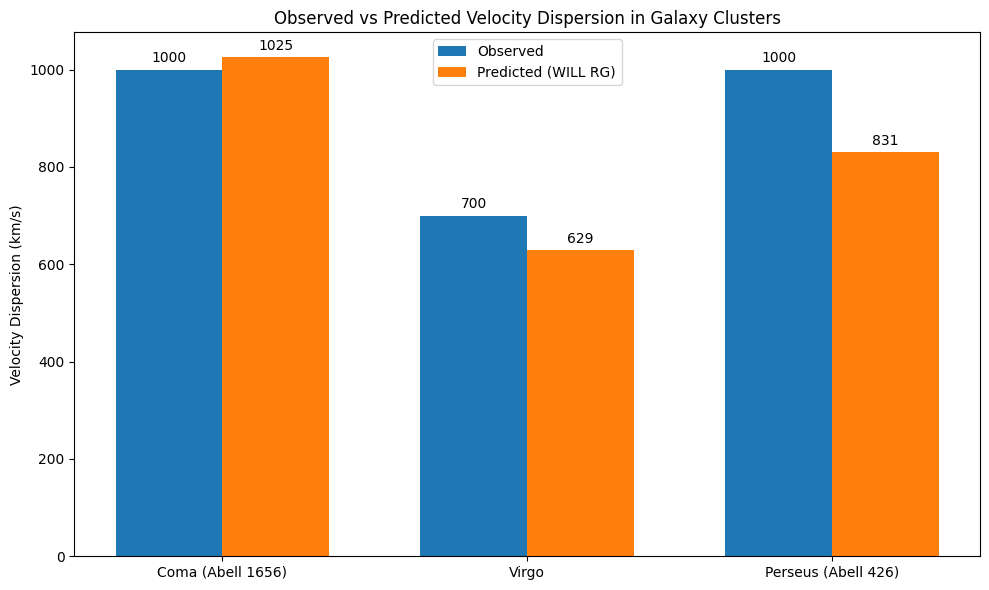

In [3]:
import matplotlib.pyplot as plt

# Setting up the plot
x = np.arange(len(df['Cluster']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, df['Sigma_obs_km_s'], width, label='Observed')
rects2 = ax.bar(x + width/2, df['Sigma_pred_km_s'], width, label='Predicted (WILL RG)')

# Adding labels and title
ax.set_ylabel('Velocity Dispersion (km/s)')
ax.set_title('Observed vs Predicted Velocity Dispersion in Galaxy Clusters')
ax.set_xticks(x)
ax.set_xticklabels(df['Cluster'])
ax.legend()

# Adding value labels on top of bars
ax.bar_label(rects1, padding=3, fmt='%.0f')
ax.bar_label(rects2, padding=3, fmt='%.0f')

fig.tight_layout()
plt.show()